## what to do
 - load data
 - scale (save as json)
 - build mode
 - eval
 - quant
 - export to h file and tflite

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
labels_names = pd.read_csv("dataset_uci/activity_labels.txt", header=None, delimiter=" ", names=["label", "activity"])
labels_names

,label,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [8]:
x_train = pd.read_csv("dataset_uci/final_X_train.txt", header=None)
y_train = pd.read_csv("dataset_uci/final_y_train.txt", header=None)

x_test = pd.read_csv("dataset_uci/final_X_test.txt", header=None)
y_test = pd.read_csv("dataset_uci/final_y_test.txt", header=None)

# print range ot y values
print("y_train range:", y_train[0].min(), "to", y_train[0].max())
print("y_test range:", y_test[0].min(), "to", y_test[0].max())

# make it from 0 to 5
y_train -= 1
y_test -= 1

print("y_train range:", y_train[0].min(), "to", y_train[0].max())
print("y_test range:", y_test[0].min(), "to", y_test[0].max())



y_train range: 1 to 6
y_test range: 1 to 6
y_train range: 0 to 5
y_test range: 0 to 5


In [9]:
# shapes

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("--------------------------------")
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (4252, 561)
y_train shape: (4252, 1)
--------------------------------
x_test shape: (1492, 561)
y_test shape: (1492, 1)


In [10]:
# data types
x_train.dtypes

0      float64
1      float64
2      float64
3      float64
4      float64
        ...   
556    float64
557    float64
558    float64
559    float64
560    float64
Length: 561, dtype: object

In [11]:
# missing values
x_train.isnull().sum()

0      0
1      0
2      0
3      0
4      0
      ..
556    0
557    0
558    0
559    0
560    0
Length: 561, dtype: int64

In [12]:
# class distribution for training set
print("Class distribution for training set:")
print(y_train.value_counts())
print("--------------------------------")
# class distribution for test set
print("Class distribution for test set:")
print(y_test.value_counts())


Class distribution for training set:
0
3    834
4    775
0    769
2    691
1    629
5    554
Name: count, dtype: int64
--------------------------------
Class distribution for test set:
0
3    289
4    254
0    243
2    239
5    238
1    229
Name: count, dtype: int64


## Data Inspection

In [13]:
# check ranges of the train data

print("Train data ranges:")
print(x_train.min().min(), "to", x_train.max().max())

Train data ranges:
-3.1233 to 7.0658


In [14]:
x_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4252 entries, 0 to 4251
Columns: 561 entries, 0 to 560
dtypes: float64(561)
memory usage: 18.2 MB


In [15]:
# data types are all float64
x_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4252 entries, 0 to 4251
Columns: 561 entries, 0 to 560
dtypes: float64(561)
memory usage: 18.2 MB


In [16]:
# check for duplicates
x_train.duplicated().sum()

# drop duplicates if any
x_train = x_train.drop_duplicates()
y_train = y_train.loc[x_train.index]


## Preprocessing
- Separate features and labels -> already done
- Encode labels into integers -> already done 

In [17]:
#Apply feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Train data ranges after scaling:")
print(x_train_scaled.min().min(), "to", x_train_scaled.max().max())

Train data ranges after scaling:
-16.854827746384903 to 55.564232635091834


In [18]:
import json

# feature order as json file
feature_order = x_train.columns.tolist()

# scaler parameters
scaler_params = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
}
# label mapping
label_mapping = dict(zip(labels_names["label"], labels_names["activity"]))

# Export all preprocessing metadata to preprocessing.json
preprocessing_metadata = {
    "feature_order": feature_order,
    "scaler_params": scaler_params,
    "label_mapping": label_mapping,
}
with open("preprocessing.json", "w") as f:
    json.dump(preprocessing_metadata, f, indent=4)

## Model Design

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

In [20]:
INPUT_SHAPE = x_train_scaled.shape[1]
NUM_CLASSES = y_train[0].nunique()

print('Input shape:', INPUT_SHAPE)
print('Number of classes:', NUM_CLASSES)

# print unique values in y_train
print('Unique labels in y_train:', y_train[0].unique())

# Convert to numpy arrays now (before tuner setup)
y_train = y_train.values.flatten()
y_test = y_test.values.flatten()


Input shape: 561
Number of classes: 6
Unique labels in y_train: [0 1 2 3 4 5]


In [21]:
# hyperparameters as a dict
hyperparameters = {
    "learning_rate": [0.0001, 0.001, 0.01],
    "batch_size": [16, 32, 64],
    "dense_units_1": [128, 256, 512],
    "dense_units_2": [64, 128, 256],
    "dropout_rate_1": [0.2, 0.3, 0.5],
    "dropout_rate_2": [0.2, 0.3, 0.5],
}


In [22]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(INPUT_SHAPE,)))
    model.add(layers.Dense(hp.Choice('dense_units_1', hyperparameters['dense_units_1']), activation='relu'))
    model.add(layers.BatchNormalization())  # stabilizes training
    model.add(layers.Dropout(hp.Choice('dropout_rate_1', hyperparameters['dropout_rate_1'])))
    model.add(layers.Dense(hp.Choice('dense_units_2', hyperparameters['dense_units_2']), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp.Choice('dropout_rate_2', hyperparameters['dropout_rate_2'])))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    optimizer = Adam(
        learning_rate=hp.Choice('learning_rate', hyperparameters['learning_rate']),
        clipnorm=1.0 
    )
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [23]:
import shutil, os
# Remove old tuner data
if os.path.exists('my_dir'):
    shutil.rmtree('my_dir')

from kerastuner import RandomSearch

turner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='human_activity_recognition'
)


/tmp/ipykernel_223720/1301535501.py:6: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import RandomSearch


In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,  
    restore_best_weights=True,
    mode='max',
    verbose=1
)


In [25]:
turner.search(
    x_train_scaled, y_train,
    validation_data=(x_test_scaled, y_test),
    epochs=50, 
    batch_size=32,
    callbacks=[checkpoint, earlystop],
)


Trial 9 Complete [00h 00m 32s]
val_accuracy: 0.8703083097934723

Best val_accuracy So Far: 0.8760053515434265
Total elapsed time: 00h 04m 29s

Search: Running Trial #10

Value             |Best Value So Far |Hyperparameter
512               |256               |dense_units_1
0.5               |0.5               |dropout_rate_1
64                |64                |dense_units_2
0.3               |0.5               |dropout_rate_2
0.0001            |0.001             |learning_rate

Epoch 1/50
107/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3616 - loss: 1.8033
Epoch 1: val_accuracy improved from None to 0.68499, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4709 - loss: 1.4322 - val_accuracy: 0.6850 - val_loss: 0.8044
Epoch 2/50
100/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6207 - loss: 0.9931
Epoch 2: val_accuracy improved from 0.68499 to 0.75804, saving model to best_model.kera

KeyboardInterrupt: 

## Float Model Evaluation

In [26]:
from tensorflow import keras
# load the best model
model = keras.models.load_model('best_model.keras')

In [27]:
# eval the model on the test set
test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 0.8592
Test Loss: 0.4271


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


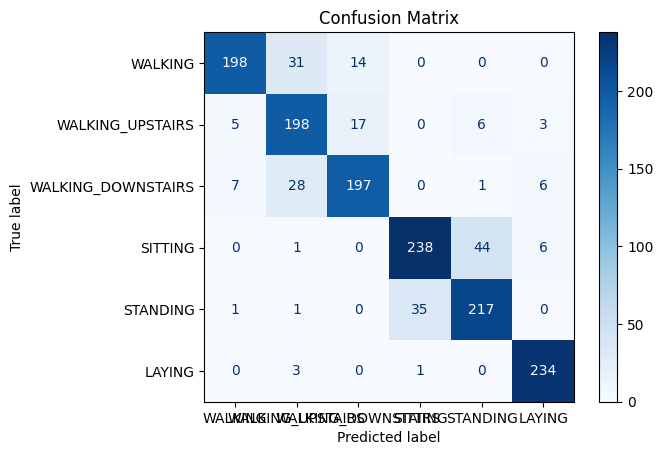

In [28]:
# Generate confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names["activity"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [29]:
# Measure model size ( in tflite format)
import os
import tensorflow as tf

# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TensorFlow Lite modelto a file
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

model_size = os.path.getsize('model.tflite') / 1024  # size in KB
print(f'Model size: {model_size:.2f} KB')

INFO:tensorflow:Assets written to: /tmp/tmp7zklbg2b/assets


INFO:tensorflow:Assets written to: /tmp/tmp7zklbg2b/assets


Saved artifact at '/tmp/tmp7zklbg2b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 561), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  130920559542736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559544272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559544656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559543888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920151790416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559543312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559542544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559544848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559542928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559546000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559545808: Tensor

W0000 00:00:1774962836.949421  223720 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774962836.949433  223720 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-31 15:13:56.949674: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7zklbg2b
2026-03-31 15:13:56.950212: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-31 15:13:56.950217: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp7zklbg2b
I0000 00:00:1774962836.954844  223720 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-31 15:13:56.955911: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-31 15:13:56.987095: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp7zklbg2b
2026-03-31 15:13:56.997067: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [30]:
# Quantize Model

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
quantized_tflite_model = converter.convert()

# Save the quantized model to a file
with open('quantized_model.tflite', 'wb') as f:
    f.write(quantized_tflite_model)

quantized_model_size = os.path.getsize('quantized_model.tflite') / 1024  # size in KB
print(f'Quantized model size: {quantized_model_size:.2f} KB')

INFO:tensorflow:Assets written to: /tmp/tmpx32p_160/assets


INFO:tensorflow:Assets written to: /tmp/tmpx32p_160/assets


Saved artifact at '/tmp/tmpx32p_160'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 561), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  130920559542736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559544272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559544656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559543888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920151790416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559543312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559542544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559544848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559542928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559546000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130920559545808: Tensor

W0000 00:00:1774962839.927344  223720 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774962839.927355  223720 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Quantized model size: 325.32 KB


2026-03-31 15:13:59.927478: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpx32p_160
2026-03-31 15:13:59.928010: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-31 15:13:59.928016: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpx32p_160
2026-03-31 15:13:59.932968: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-31 15:13:59.965602: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpx32p_160
2026-03-31 15:13:59.975561: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 48084 microseconds.


In [31]:
print("float model size:", model_size, "KB")
print("quantized model size:", quantized_model_size, "KB")
print(f'Model size reduced by: {model_size - quantized_model_size:.2f} KB ({(model_size - quantized_model_size) / model_size * 100:.2f}%)')

float model size: 1256.01953125 KB
quantized model size: 325.3203125 KB
Model size reduced by: 930.70 KB (74.10%)


In [34]:
# evaluate using tflite model
interpreter = tf.lite.Interpreter(model_path='quantized_model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run inference sample by sample
tflite_predictions = []

for i in range(len(x_test_scaled)):
    sample = x_test_scaled[i].reshape(1, -1).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    tflite_predictions.append(output[0])

tflite_predictions = np.array(tflite_predictions)
tflite_pred_classes = np.argmax(tflite_predictions, axis=1)

# Accuracy
from sklearn.metrics import accuracy_score, classification_report
print("TFLite Accuracy:", accuracy_score(y_test, tflite_pred_classes))
print(classification_report(y_test, tflite_pred_classes, target_names=labels_names['activity']))

TFLite Accuracy: 0.8585790884718498
                    precision    recall  f1-score   support

           WALKING       0.94      0.81      0.87       243
  WALKING_UPSTAIRS       0.76      0.86      0.81       229
WALKING_DOWNSTAIRS       0.86      0.82      0.84       239
           SITTING       0.87      0.82      0.84       289
          STANDING       0.81      0.85      0.83       254
            LAYING       0.94      0.98      0.96       238

          accuracy                           0.86      1492
         macro avg       0.86      0.86      0.86      1492
      weighted avg       0.86      0.86      0.86      1492



In [35]:
# export to header file

with open('tflite_model.h', 'w') as f:
    f.write('#include <cstdint>\n\n')
    f.write('const unsigned char model[] = {')
    for i, byte in enumerate(tflite_model):
        if i % 12 == 0:
            f.write('\n    ')
        f.write(f'0x{byte:02x}, ')
    f.write('\n};\n')
    f.write(f'const unsigned int model_len = {len(tflite_model)};\n')
